<a href="https://colab.research.google.com/github/hoffmanpeyton14-art/IT480-FA26/blob/main/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Hyperparameter Tuning and Fixing Overfitting

**Name:** Peyton Hoffman and Jazmin Correa


In [33]:
!pip install keras-tuner --quiet

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [35]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

# Part A - Restate Your Baseline

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
quality_band
0    744
1    638
2    217
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


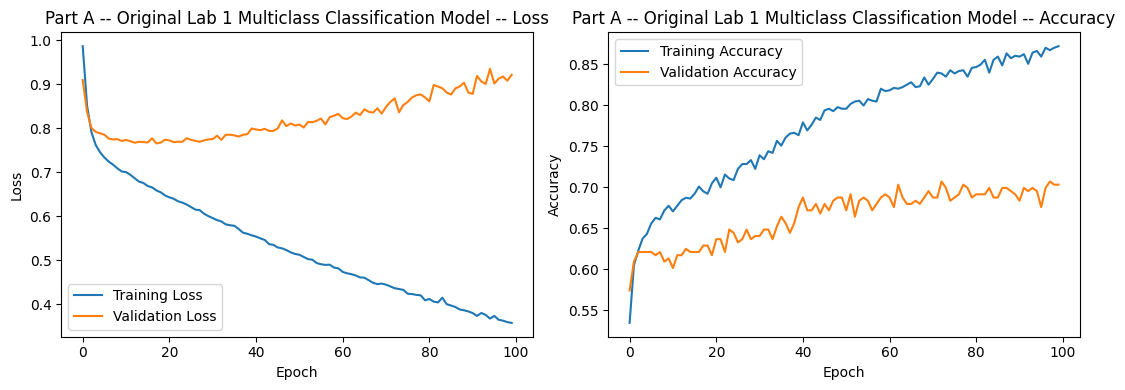

In [36]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

n_classes = len(np.unique(y3))
n_features = X3_train_scaled.shape[1]

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part A -- Original Lab 1 Multiclass Classification Model", show_accuracy=True)

## Part A Original Lab 1 Results

My original model had a test accuracy of 68.4%. It started overfitting around epochs 15–20 because training performance continued improving while validation performance became worse. This shows that the model learned the training data too closely.

# Part B: Hyperparameter Tuning

In [37]:
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            hp.Int("hidden1", min_value=16, max_value=128, step=16),
            activation="relu", input_shape=(n_features,)
        ),
        tf.keras.layers.Dense(
            hp.Int("hidden2", min_value=8, max_value=64, step=8),
            activation="relu"
        ),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
           hp.Choice("learning_rate",[0.001, 0.01, 0.1])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    overwrite=True
)

tuner.search(
    X3_train_scaled, y3_train,
    validation_split=0.2, epochs=50, verbose=0
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print("Best Hyperparameters:", best_hp.values)
print(f"Best Validation Loss: {best_trial.score:.3f}")

Best Hyperparameters: {'hidden1': 80, 'hidden2': 48, 'learning_rate': 0.01}
Best Validation Loss: 0.770


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


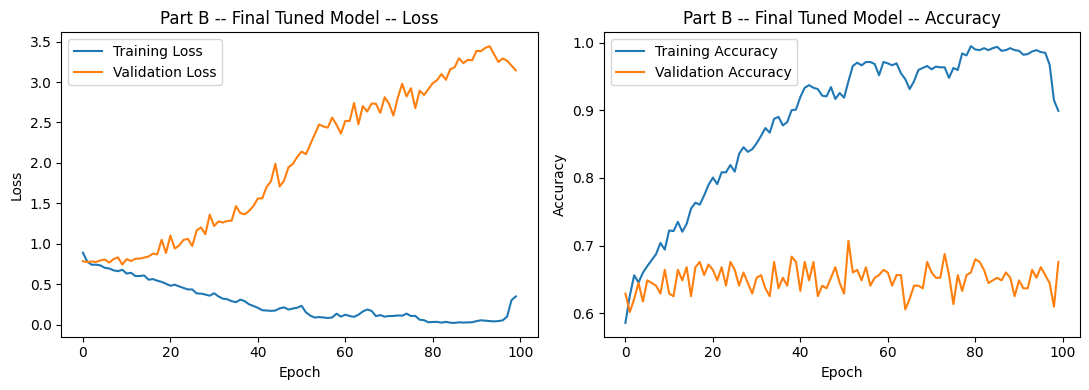

In [38]:
final_tuned_model = build_model(best_hp)

history_tuned = final_tuned_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_tuned, "Part B -- Final Tuned Model", show_accuracy=True)

In [39]:
tuned_test_loss, tuned_test_accuracy = final_tuned_model.evaluate(
    X3_test_scaled,
    y3_test,
    verbose=0
)

accuracy_change = tuned_test_accuracy - 0.684

print(f"Tuned Model Test Accuracy: {tuned_test_accuracy:.3f}")
print(f"Accuracy Change: {accuracy_change:+.3f}")

Tuned Model Test Accuracy: 0.691
Accuracy Change: +0.007


## Part B Results

I used Keras Tuner to test different layer sizes and learning rates using only the training and validation data. The best model had 80 neurons in the first layer, 48 neurons in the second layer, and a learning rate of 0.01. Its validation loss was 0.770.

The tuned model had a test accuracy of 69.1%, compared to the original accuracy of 68.4%. This was a small improvement of 0.7 percentage points, but the graph shows that the model still overfits.

# Part C: Addressing Overfitting

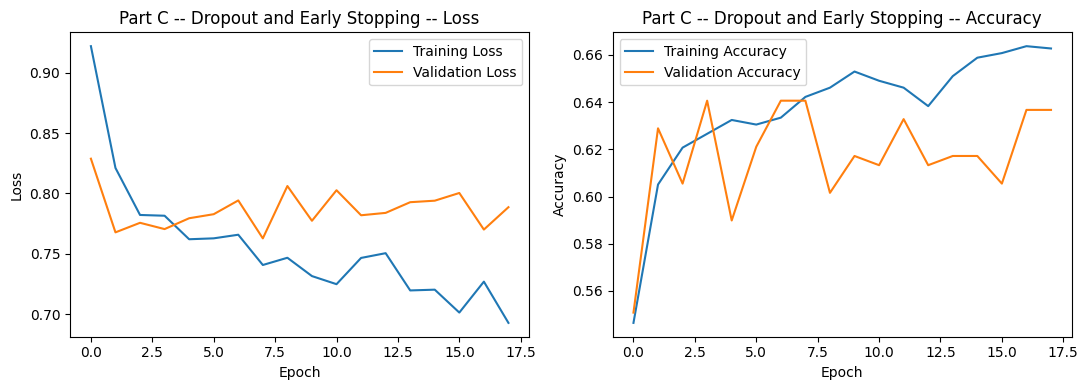

In [45]:
regularized_model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        best_hp.get("hidden1"), activation="relu", input_shape=(n_features,)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(best_hp.get("hidden2"), activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

regularized_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_hp.get("learning_rate")
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_regularized = regularized_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stop],
    verbose=0
)

plot_history(history_regularized, "Part C -- Dropout and Early Stopping", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Final Test Accuracy: 0.656


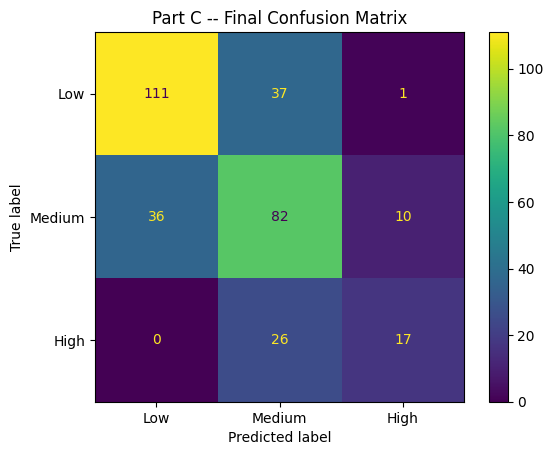

In [46]:
final_probs = regularized_model.predict(X3_test_scaled)
final_preds = np.argmax(final_probs, axis=1)

final_accuracy = accuracy_score(y3_test, final_preds)
print(f"Final Test Accuracy: {final_accuracy:.3f}")

final_cm = confusion_matrix(y3_test, final_preds)
ConfusionMatrixDisplay(final_cm, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part C -- Final Confusion Matrix")
plt.show()

## Part C Results

Dropout and Early Stopping reduced the overfitting. The training and validation curves stayed much closer together, and validation loss did not rise sharply like it did in Part A. Early Stopping ended training after about 17-18 epochs.

The final test accuracy was 65.6%, which was lower than the original 68.4%. The model still confused Low and Medium wines most often. This was similar to the original model, so the main type of confusion did not change.

# Part D: Reflection

1. Why is it important that your test set was touched only once, at the very end?

2. What would have gone wrong if you had used your test set to pick the best hyperparameter
configuration instead of a validation split?

3. Did Dropout or Early Stopping meaningfully reduce the overfitting you saw in Lab 1? What
evidence from your new loss curve supports your answer?

4. If you had unlimited time and compute, what would you try next to improve this model further?

**It is important to save the test set until the end so it gives an honest measure of how the model performs on new data. If I used the test set to choose the hyperparameters, the model would become fitted to the test data and the final accuracy would be misleading. Dropout and Early Stopping reduced the overfitting because the training and validation curves stayed much closer together. Validation loss also stopped rising sharply, although the final accuracy decreased to 65.6%. With unlimited time and computing power, I would test more hyperparameters, Dropout rates, and model sizes to find a better balance between accuracy and overfitting.**